<a href="https://colab.research.google.com/github/OlhaZahrebelna/my_first_repo/blob/main/Project_Taxi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

Download data set

In [2]:
df_taxi = sns.load_dataset('taxis')

In [4]:
df_taxi.head(2)

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan


**Type and size of the date set**

In [5]:
df_taxi.dtypes , df_taxi.shape

(pickup             datetime64[ns]
 dropoff            datetime64[ns]
 passengers                  int64
 distance                  float64
 fare                      float64
 tip                       float64
 tolls                     float64
 total                     float64
 color                      object
 payment                    object
 pickup_zone                object
 dropoff_zone               object
 pickup_borough             object
 dropoff_borough            object
 dtype: object,
 (6433, 14))

**Check for missing data**

In [6]:
df_taxi.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [7]:
df_isna_dropoff_zone = df_taxi[df_taxi.dropoff_zone.isna()]
df_isna_dropoff_zone

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
42,2019-03-30 23:59:14,2019-03-30 23:59:17,1,0.00,80.0,20.08,0.00,100.38,yellow,credit card,NaN,NaN,NaN,NaN
622,2019-03-12 19:52:36,2019-03-12 19:52:55,3,0.00,120.0,33.20,12.50,166.00,yellow,credit card,NaN,NaN,NaN,NaN
711,2019-03-21 17:39:50,2019-03-21 18:12:54,2,1.74,17.0,4.26,0.00,25.56,yellow,credit card,Midtown East,NaN,Manhattan,NaN
739,2019-03-14 00:09:17,2019-03-14 00:09:21,1,0.03,2.5,0.00,0.00,3.80,yellow,cash,Upper East Side South,NaN,Manhattan,NaN
970,2019-03-29 00:02:00,2019-03-29 00:02:05,2,0.00,45.0,5.00,0.00,50.30,yellow,credit card,NaN,NaN,NaN,NaN
1108,2019-03-10 09:33:13,2019-03-10 09:52:04,1,13.40,52.0,11.70,5.76,70.26,yellow,credit card,NaN,NaN,NaN,NaN
1112,2019-03-12 19:09:23,2019-03-12 19:20:46,1,0.90,8.5,1.92,0.00,14.72,yellow,credit card,Times Sq/Theatre District,NaN,Manhattan,NaN
1230,2019-03-29 07:52:46,2019-03-29 08:02:40,1,0.90,5.5,1.76,0.00,10.56,yellow,credit card,Yorkville East,NaN,Manhattan,NaN
1690,2019-03-22 06:24:14,2019-03-22 06:24:14,1,0.00,72.0,0.00,0.00,72.00,yellow,NaN,East New York,NaN,Brooklyn,NaN
1787,2019-03-28 06:58:57,2019-03-28 07:18:10,1,6.32,20.5,4.26,0.00,25.56,yellow,credit card,Manhattan Valley,NaN,Manhattan,NaN


Why do these lines have lagging data in several columns?
* I think. It is cancelled trips. However, the indicated cost is explained by the fact that the driver was driving to the client, so a fee is charged for expenses (fuel, toll roads, etc.). In this case, in the columns pickup_zone, dropoff_zone, pickup_borough, and dropoff_borough it can be noted that the trip is canceled. If the column indicates the distance, it means that the trip was canceled during the route. For example, a passenger could leave earlier due to a traffic jam, deciding to continue on the subway.

In [8]:
df_taxi_clean = df_taxi.fillna('NA')

In [9]:
df_taxi_clean.isna().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


**Create new column**

In [10]:
df_taxi_clean['pickup_day'] = df_taxi_clean.pickup.dt.floor('d')

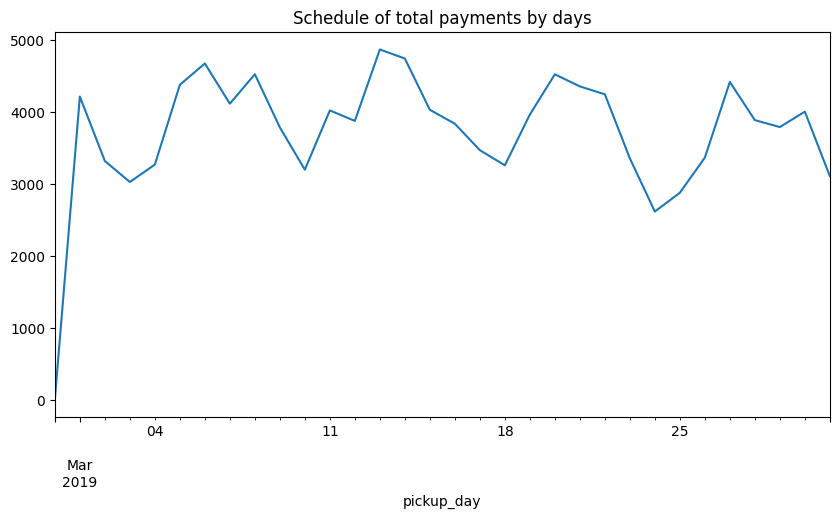

In [11]:
plt.figure(figsize=(10,5))
df_taxi_clean.groupby('pickup_day').total.sum().plot()
plt.title('Schedule of total payments by days');

* I see something strange at the beginning of the plot

In [12]:
df_taxi_clean.groupby('pickup_day').size()

,0
pickup_day,
2019-02-28,1
2019-03-01,241
2019-03-02,198
2019-03-03,169
2019-03-04,171
2019-03-05,228
2019-03-06,257
2019-03-07,218
2019-03-08,235


* Looks like this entry(2019-02-28) was added by mistake.

In [13]:
df_taxi_clean = df_taxi_clean[df_taxi_clean != '2019-02-28']
df_taxi_clean.groupby('pickup_day').size()

,0
pickup_day,
2019-03-01,241
2019-03-02,198
2019-03-03,169
2019-03-04,171
2019-03-05,228
2019-03-06,257
2019-03-07,218
2019-03-08,235
2019-03-09,204


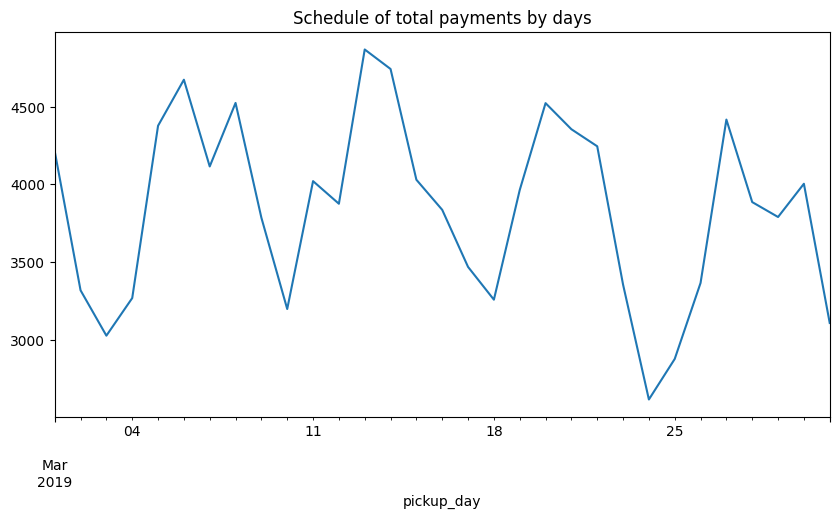

In [14]:
plt.figure(figsize=(10,5))
df_taxi_clean.groupby('pickup_day').total.sum().plot()
plt.title('Schedule of total payments by days');

In [15]:
borough_pivot = df_taxi_clean.pivot_table(index='pickup_day', columns='pickup_borough', values='total', aggfunc='sum',fill_value=0  )
borough_pivot = borough_pivot.drop(columns='NA')

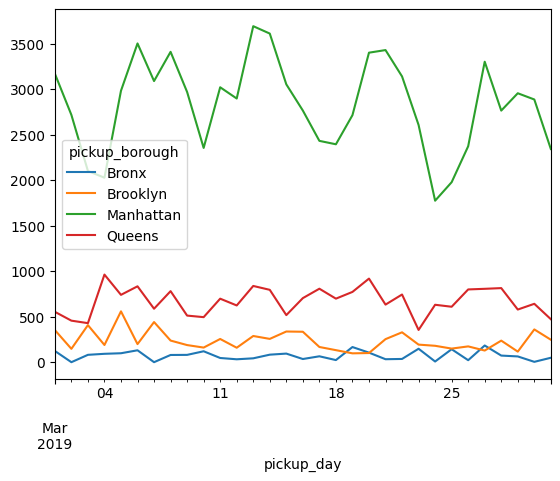

In [16]:
borough_pivot.fillna(0).plot();

* More drive payments for rides in Manhattan

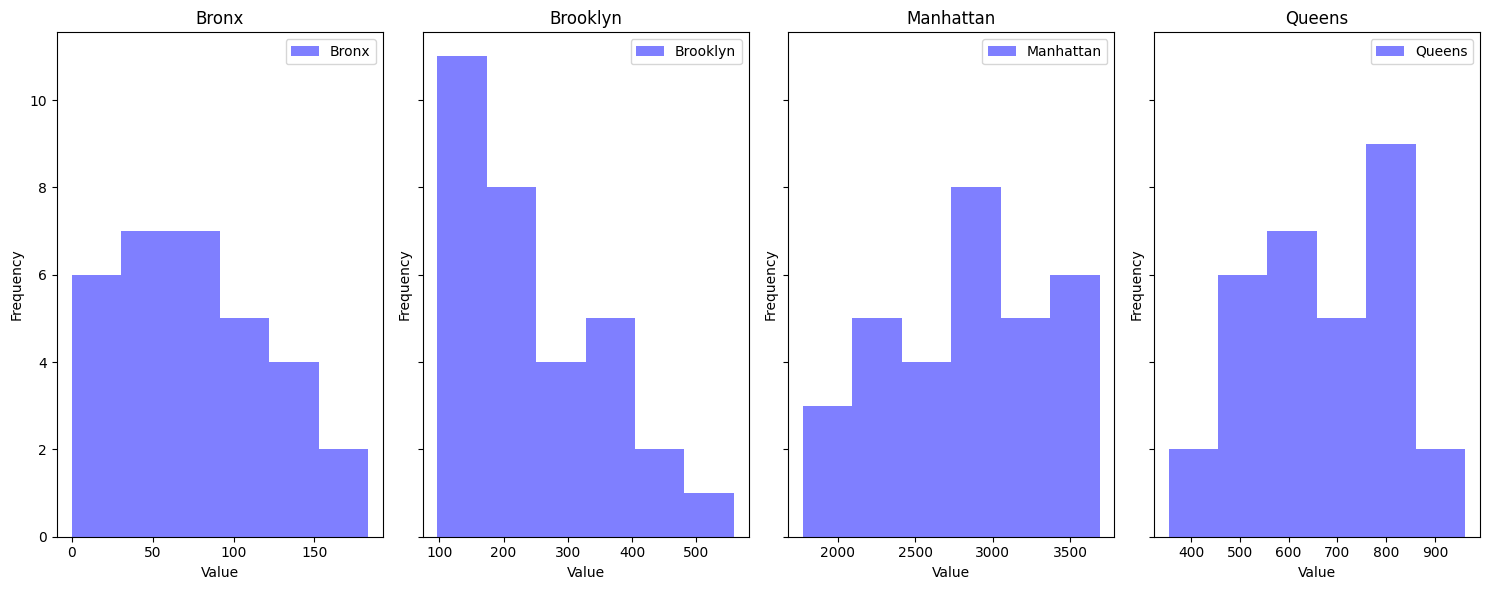

In [17]:
fig, axs = plt.subplots(nrows=1, ncols=len(borough_pivot.columns), figsize=(15, 6), sharey=True)

for i, col in enumerate(borough_pivot.columns):
  axs[i].hist(borough_pivot[col], bins=6, alpha=0.5, label=col, color='blue')
  axs[i].set_title(f'{col}')
  axs[i].set_xlabel('Value')
  axs[i].set_ylabel('Frequency')
  axs[i].legend()
  plt.tight_layout()

These histograms represent the distribution of some metric  across four boroughs of New York City: Bronx, Brooklyn, Manhattan, and Queens.
* Bronx: The distribution here shows that most values are concentrated at the lower end of the scale, with a gradual decline as values increase. This suggests that in the Bronx, the majority of rides or payments are relatively low compared to the other boroughs.
* Brooklyn: Similar to the Bronx, Brooklyn also shows a concentration of lower values, though there is a wider spread. This indicates that while many rides or payments are low, there are instances of higher values, possibly reflecting a more diverse range of travel distances or payment amounts.
* Manhattan: Unlike the Bronx and Brooklyn, Manhattan has a distribution with a peak at higher values. This could indicate that rides in Manhattan tend to be more expensive or cover longer distances, which aligns with the higher demand and density of the area.
* Queens: The distribution in Queens shows a more balanced spread across mid-to-high values, with a peak around the middle. This could suggest that ride payments or distances in Queens are generally moderate but have occasional higher values.

Overall, these histograms provide insight into the variation in taxi service usage or cost across NYC boroughs. Manhattan stands out with higher values, likely due to its central role in business and tourism.

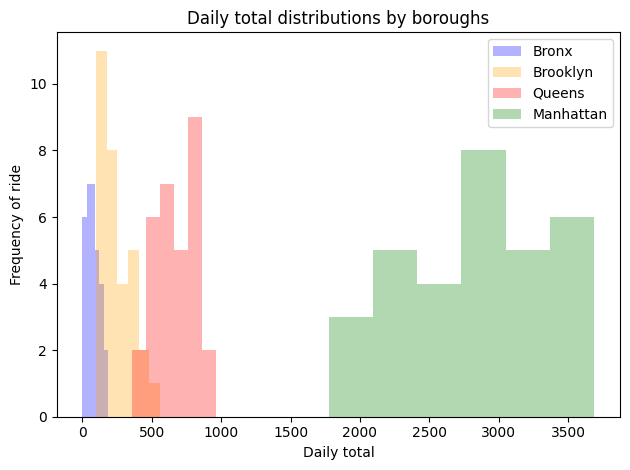

In [18]:
plt.hist(borough_pivot['Bronx'], bins=6, alpha=0.3, label='Bronx', color='blue')
plt.hist(borough_pivot['Brooklyn'], bins=6, alpha=0.3, label='Brooklyn', color='orange')
plt.hist(borough_pivot['Queens'], bins=6, alpha=0.3, label='Queens', color='red')
plt.hist(borough_pivot['Manhattan'], bins=6, alpha=0.3, label='Manhattan', color='green')
plt.title('Daily total distributions by boroughs')
plt.xlabel('Daily total')
plt.ylabel('Frequency of ride')
plt.legend()
plt.tight_layout();

This histogram visualizes the distribution of daily total rides across four New York City boroughs: Bronx, Brooklyn, Queens, and Manhattan.

* Bronx and Brooklyn show a concentration of lower daily totals, suggesting that the frequency of rides in these boroughs tends to stay on the lower level. This could indicate a lower demand for taxi services or shorter distances for typical rides.
* Queens has a moderate spread, with most of its daily totals falling between 400 and 800, indicating a slightly higher frequency of rides compared to Bronx and Brooklyn, though still not reaching the levels of Manhattan.
* Manhattan stands out with a much higher daily total range, peaking around 2500-3500. This pattern suggests a significantly higher volume of taxi rides, likely due to Manhattan’s role as a central business and tourist hub, resulting in higher demand and potentially longer trips.

Overall, the histogram shows clear differences in taxi usage among the boroughs, with Manhattan having the highest daily totals, while Bronx and Brooklyn have the lowest.

It is the same data only other visualization.

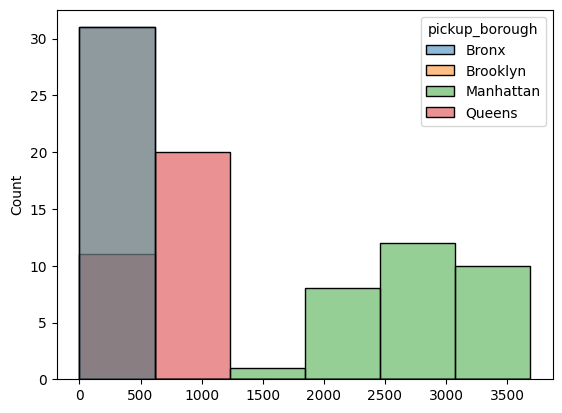

In [19]:
sns.histplot(data=borough_pivot, bins=6);

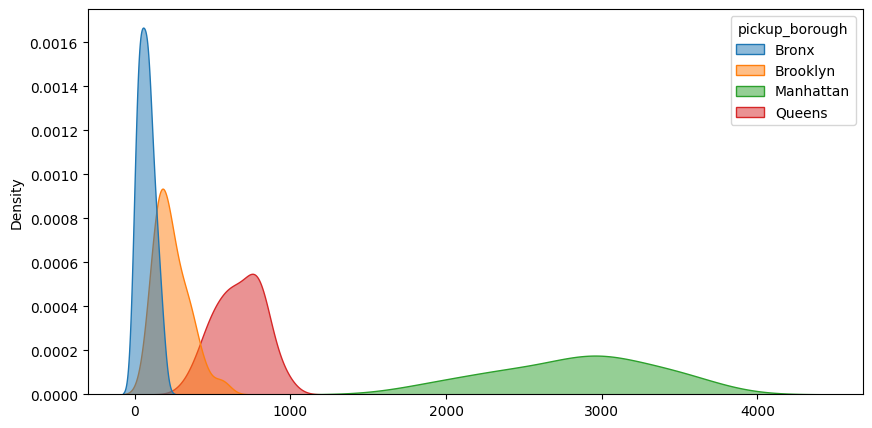

In [20]:
plt.figure(figsize=(10,5))
sns.kdeplot(borough_pivot, fill=True, alpha=0.5);

**Histogram of the amount of monthly payments by car colors.**

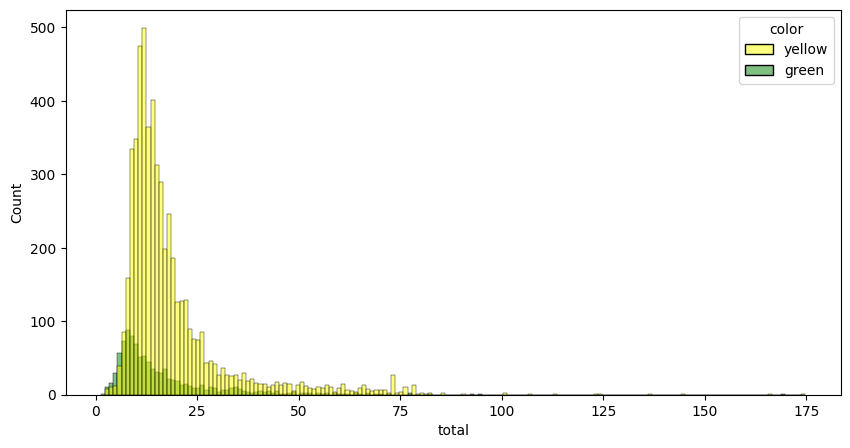

In [22]:
plt.figure(figsize=(10, 5), dpi=100)
sns.histplot(data=df_taxi_clean, x='total', hue='color', palette={'yellow': 'yellow', 'green': 'green'});

* Is there a relationship between travel range and tip size?

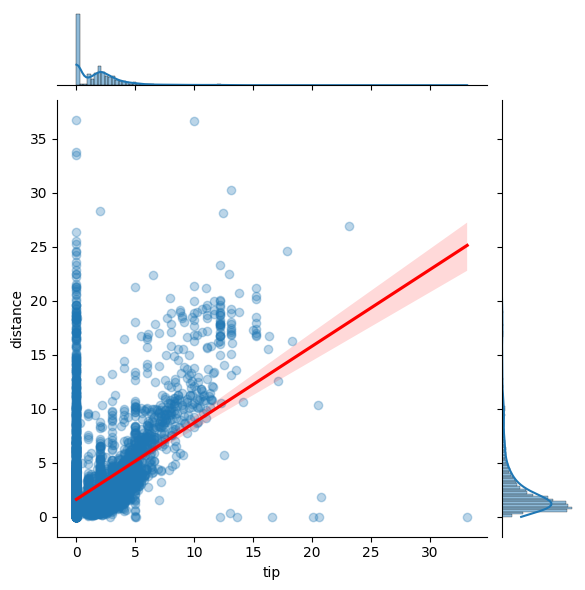

In [23]:
sns.jointplot(data=df_taxi_clean, x='tip', y='distance', kind='reg', line_kws={'color': 'red'}, scatter_kws={'alpha': 0.3});

* A straight line from the points means customers have not left a tip within journeys of 0 to 27 km. However, we also have three cases with greater distance when the tip was not paid.

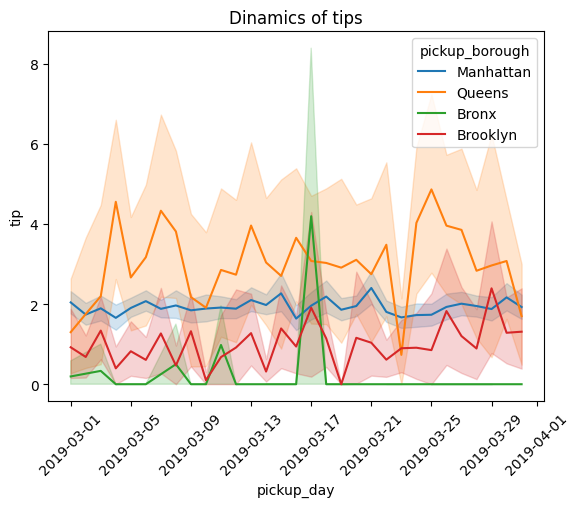

In [24]:
df_taxi_clean_without_NA = df_taxi_clean[df_taxi_clean.pickup_borough != 'NA']
sns.lineplot(data=df_taxi_clean_without_NA, x='pickup_day', y='tip', hue='pickup_borough')
plt.xticks(rotation=45)
plt.title('Dinamics of tips');

* lowest average tip size Bronx
* Highest average tip size Queens
* Tip size most stable (least changing from day to day) Manhattan

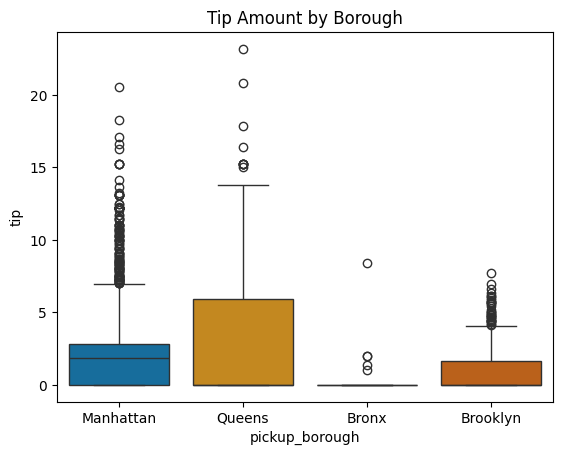

In [26]:
sns.boxplot(data=df_taxi_clean_without_NA, x='pickup_borough', y='tip', hue='pickup_borough', palette='colorblind')
plt.title("Tip Amount by Borough");

* Manhattan: In Manhattan, the tip distribution is quite wide, with a high median and a significant number of samples above average. This may indicate that larger tips are usually given in Manhattan.
* Queens: Relatively high tips can also be observed in Queens, although the range is not as wide as in Manhattan.
* Bronx: In the Bronx, the median tip is significantly lower and the distribution itself is narrow, suggesting smaller tip sizes in the area.
* Brooklyn: Brooklyn has a very low median tip, and the values   themselves have a large spread, but generally less than in Manhattan and Queens.


In [27]:
df_taxi_clean['day_of_week'] = df_taxi_clean.pickup.dt.weekday
df_taxi_clean['hour_of_day'] = df_taxi_clean.pickup.dt.hour

**These schedules will help in planning driver schedules.**

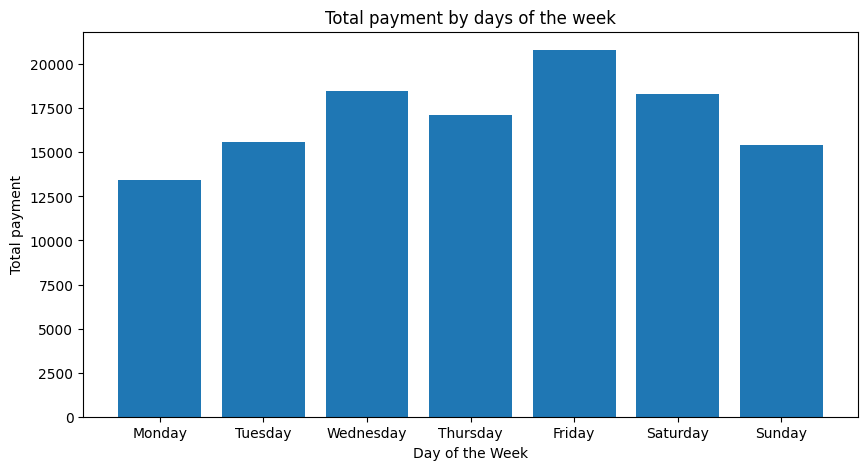

In [28]:
fig = plt.figure(figsize=(10,5))

daily_total_payments = df_taxi_clean.groupby('day_of_week')['total'].sum()

plt.bar(daily_total_payments.index, daily_total_payments.values)
plt.xticks(daily_total_payments.index, ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.xlabel('Day of the Week')
plt.ylabel('Total payment')
plt.title('Total payment by days of the week');

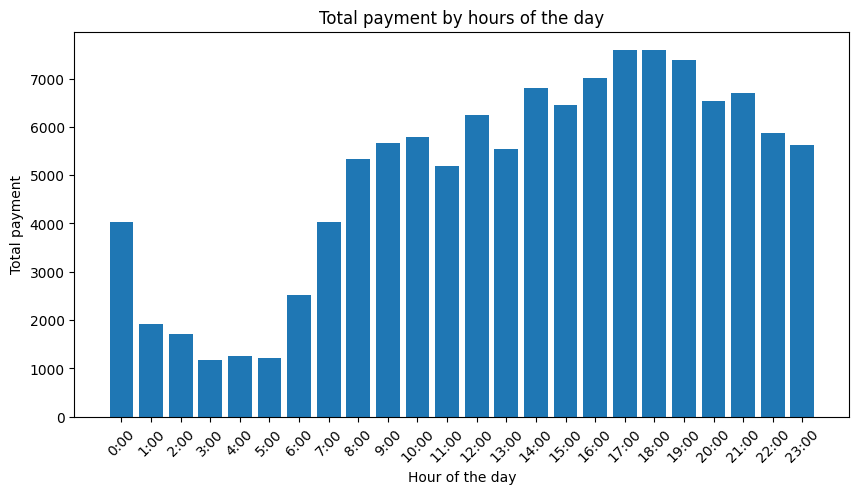

In [29]:
fig = plt.figure(figsize=(10,5))

hourly_total_payments = df_taxi_clean.groupby('hour_of_day')['total'].sum()

plt.bar(hourly_total_payments.index, hourly_total_payments.values)
plt.xticks(hourly_total_payments.index, [f'{i}:00' for i in range(24)], rotation=45)
plt.xlabel('Hour of the day')
plt.ylabel('Total payment')
plt.title('Total payment by hours of the day');

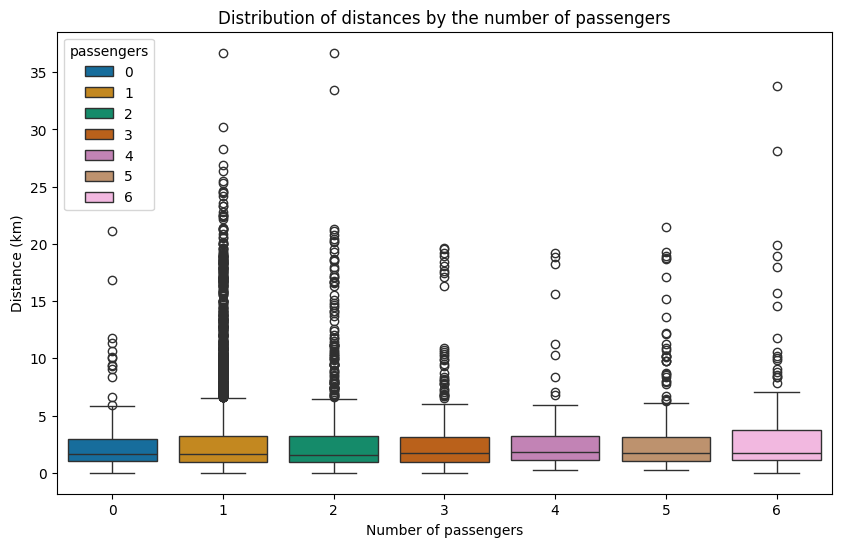

In [30]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_taxi_clean, x='passengers', y='distance', hue='passengers', palette='colorblind');

plt.title('Distribution of distances by the number of passengers')
plt.xlabel('Number of passengers')
plt.ylabel('Distance (km)');

* Unfortunately, there is no clear correlation between distance and the number of passengers. There are many outliers, especially for trips with one or two passengers, but the median for these groups appears the same. However, we observe that there are trips with more than four passengers. There are also cases with zero passengers, which likely indicate deliveries from point A to point B. We need to identify the difference between the groups with 0-3 passengers and those with 4-6 passengers to determine whether it would be beneficial to increase the number of vehicles with larger passenger capacity.

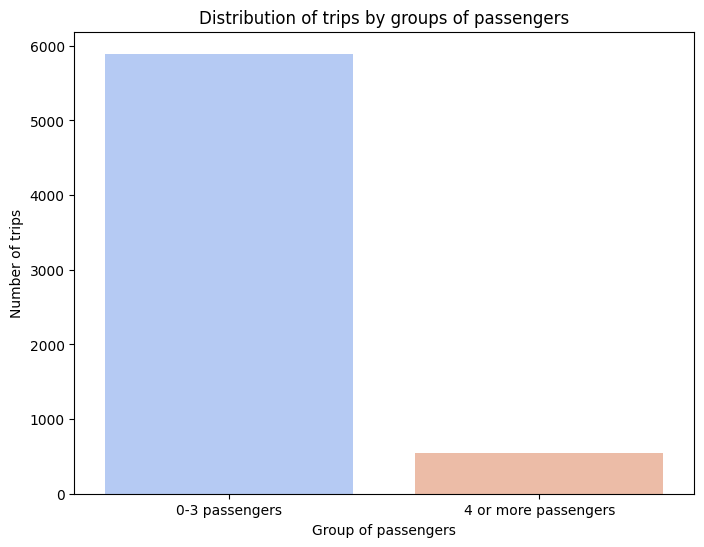

In [31]:
df_taxi_clean['passenger_group'] = df_taxi_clean['passengers'].apply(lambda x: '0-3 passengers' if x <= 3 else '4 or more passengers')

group_counts = df_taxi_clean['passenger_group'].value_counts().reset_index()
group_counts.columns = ['passenger_group', 'count']

plt.figure(figsize=(8, 6))
sns.barplot(x='passenger_group', y='count', data=group_counts,hue='passenger_group', palette='coolwarm')

plt.title('Distribution of trips by groups of passengers')
plt.xlabel('Group of passengers')
plt.ylabel('Number of trips');

* We have not a large number when there are more than 3 passengers. There is no need for more cars with more passenger seats.

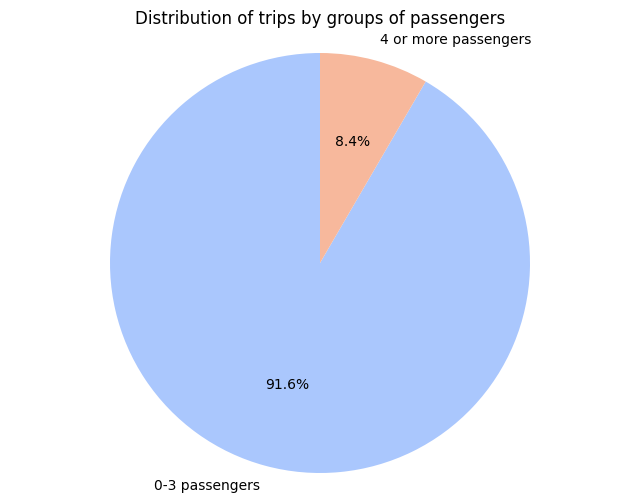

In [33]:
plt.figure(figsize=(8, 6))
plt.pie(group_counts['count'], labels=group_counts['passenger_group'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('coolwarm', len(group_counts)))

plt.title('Distribution of trips by groups of passengers')
plt.axis('equal');